# Chapter 2: Data and Sampling Distributions
> (c) 2019-2026 Peter C. Bruce, Andrew Bruce, Peter Gedeck

In [1]:
from scipy import stats
from sklearn.utils import resample
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
import seaborn as sns

random.seed(123)

# Location of the data files. Adjust this path if you keep the data
# files in a different directory.
from pathlib import Path
DATA_DIR = Path('../../data')


## Data and Sampling Distributions
### Sampling Distribution of a Statistic

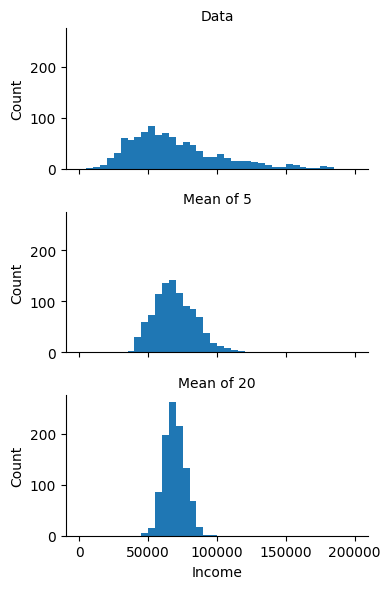

In [1]:
loans_income = pd.read_csv(DATA_DIR / "loans_income.csv").squeeze("columns")

sample_data = pd.DataFrame({
    "income": loans_income.sample(1000),
    "type": "Data",
})
sample_mean_05 = pd.DataFrame({
    "income": [loans_income.sample(5).mean() for _ in range(1000)],
    "type": "Mean of 5",
})
sample_mean_20 = pd.DataFrame({
    "income": [loans_income.sample(20).mean() for _ in range(1000)],
    "type": "Mean of 20",
})
results = pd.concat([sample_data, sample_mean_05, sample_mean_20])

g = sns.FacetGrid(results, col="type", col_wrap=1, height=2, aspect=2)
g.map(plt.hist, "income", range=[0, 200000], bins=40)
g.set_axis_labels("Income", "Count")
g.set_titles("{col_name}")

plt.tight_layout()
plt.show()

### The Bootstrap

In [1]:
res = stats.bootstrap([loans_income], np.median, n_resamples=1000,
    method="basic")

print("Bootstrap Statistics:")
print(f"original: {np.median(loans_income)}")
print(f"bias: {np.mean(res.bootstrap_distribution) - np.median(loans_income)}")
print(f"std. error: {res.standard_error}")
print(f"confidence interval: {res.confidence_interval}")

Bootstrap Statistics:
original: 62000.0
bias: -75.51699999999983
std. error: 228.04348717523823
confidence interval: ConfidenceInterval(low=np.float64(62000.0), high=np.float64(62986.8375))


In [1]:
# alternative using scikit-learns's resample function

results = []
for _ in range(1000):
    sample = resample(loans_income)
    results.append(sample.median())
results = pd.Series(results)
print("Bootstrap Statistics:")
print(f"original: {loans_income.median()}")
print(f"bias: {results.mean() - loans_income.median()}")
print(f"std. error: {results.std()}")

Bootstrap Statistics:
original: 62000.0
bias: -77.3324999999968
std. error: 224.84385571592387


### Normal Distribution
#### Standard Normal and QQ-Plots

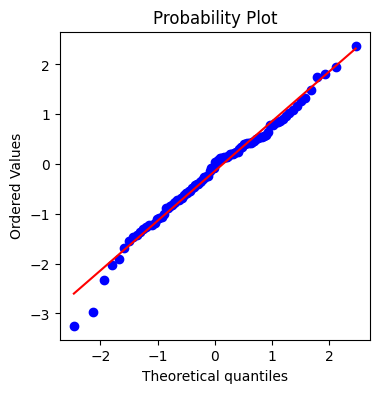

In [1]:
fig, ax = plt.subplots(figsize=(4, 4))
norm_sample = stats.norm.rvs(size=100)
stats.probplot(norm_sample, plot=ax)
plt.show()

### Long-Tailed Distributions

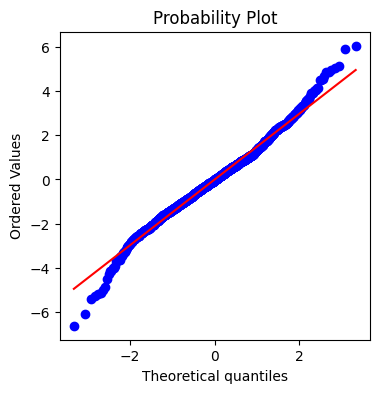

In [1]:
sp500_px = pd.read_csv(DATA_DIR / "sp500_data.csv.gz")

nflx = sp500_px.NFLX
nflx = np.diff(np.log(nflx[nflx > 0]))
fig, ax = plt.subplots(figsize=(4, 4))
stats.probplot(nflx, plot=ax)
plt.show()

### Binomial Distribution

In [1]:
print(stats.binom.pmf(2, n=5, p=0.1))
print(stats.binom.cdf(2, n=5, p=0.1))

0.07289999999999995
0.99144


### Poisson and Related Distributions
#### Poisson Distributions

In [1]:
stats.poisson.rvs(2, size=100)

array([1, 4, 1, 2, 3, 3, 1, 3, 2, 2, 1, 2, 2, 2, 1, 1, 0, 2, 2, 1, 7, 2,
       2, 3, 2, 3, 4, 2, 2, 4, 3, 0, 1, 0, 3, 1, 0, 2, 0, 1, 5, 2, 5, 3,
       3, 3, 1, 0, 4, 3, 2, 1, 2, 1, 0, 0, 3, 2, 3, 4, 2, 3, 5, 2, 4, 4,
       3, 4, 2, 6, 2, 2, 1, 1, 1, 1, 2, 2, 3, 4, 1, 2, 2, 2, 1, 0, 2, 3,
       0, 2, 1, 1, 1, 2, 4, 2, 1, 0, 4, 1])

#### Exponential Distribution

In [1]:
stats.expon.rvs(scale=1 / 0.2, size=100)
stats.expon.rvs(scale=5, size=100)

array([ 8.09783483,  1.66090921,  0.72910778,  0.22779291,  0.2391516 ,
        0.29270177,  7.00625622,  1.27605592, 10.95904487,  0.39386107,
        6.32833091,  2.76645821,  1.21222966,  4.43368186,  0.35951793,
        1.19183029,  2.15696792,  3.60392384,  2.28959833,  0.8717584 ,
        2.71931752, 10.30839282,  0.38079347,  6.35159244,  9.63134239,
        8.82365745,  5.10587408, 13.84160164,  2.75115014,  1.50234928,
        8.33863386,  5.55112579,  1.56260272,  2.66614382,  3.21832452,
        1.49846191,  4.72206623, 11.12271612,  1.07480813,  2.49311103,
        0.28956544,  4.54587018,  7.57496943,  1.63918712,  6.32210391,
        0.78273095,  1.59830155,  2.01762688,  7.51124786, 10.98004882,
        2.66380023,  6.85463906,  0.51999569,  2.09008551,  3.77240214,
       11.16238825,  9.95902328,  2.83890962, 11.32824305,  2.17346367,
        0.3232556 , 19.35832172,  5.31494483,  7.02270902,  0.79269754,
        2.32034758,  0.06448456,  1.30977463,  4.10272553, 10.32

#### Weibull Distribution

In [1]:
stats.weibull_min.rvs(1.5, scale=5000, size=100)

array([ 2139.04602154,  5240.78143966,  1570.37465655,  6197.76095162,
        6019.70478273,  1279.03260649,  6419.45361906,  3280.53319212,
        9774.52202293,  2128.39890643,  2700.78708674,  3760.20120883,
        5847.44487806,  6524.65218159,  5318.97734704,  2647.42636494,
        1582.22070521,   553.47570315,   598.15205805,  4148.01223472,
        1413.85800741,  3640.95480026,  7550.61890059,  9472.35928305,
        1307.32617842,  2766.5607829 ,  1577.47487091,  1761.19036275,
        1940.79847449,   177.73090235,  9685.97158454,  7830.34170061,
        6147.85234729,  2507.87814014,  1109.82487341,  4445.64812287,
       10013.38774786,  8393.40164019,  1975.52058784,  1813.72110925,
        9890.69061386,   678.76085154,  1784.35874099,  7362.8504281 ,
        1884.85220975,  4772.65101348,  6348.17443677, 10354.26856788,
        4801.84306285,  2926.90717098,  6804.94875895,  1505.73498078,
        8060.75104471,  8738.05903759,  2124.45763921,  1048.16554624,
      

# Supplementary Material
## Figure 2-9 Bootstrap confidence interval for the annual income of loan applicants, based on a sample of 20

68760.51844
55734.1


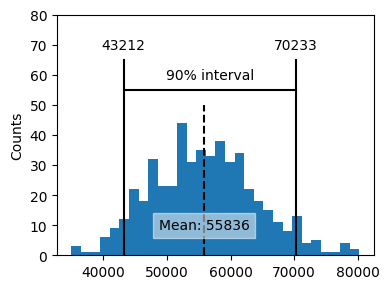

In [1]:
print(loans_income.mean())
np.random.seed(seed=3)

# create a sample of 20 loan income data
sample20 = resample(loans_income, n_samples=20, replace=False)
print(sample20.mean())
results = []
for _ in range(500):
    sample = resample(sample20)
    results.append(sample.mean())
results = pd.Series(results)

confidence_interval = list(results.quantile([0.05, 0.95]))
ax = results.plot.hist(bins=30, figsize=(4, 3))
ax.plot(confidence_interval, [55, 55], color="black")
for x in confidence_interval:
    ax.plot([x, x], [0, 65], color="black")
    ax.text(x, 70, f"{x:.0f}", horizontalalignment="center", verticalalignment="center")
ax.text(sum(confidence_interval) / 2, 60, "90% interval",
        horizontalalignment="center", verticalalignment="center")

meanIncome = results.mean()
ax.plot([meanIncome, meanIncome], [0, 50], color="black", linestyle="--")
ax.text(meanIncome, 10, f"Mean: {meanIncome:.0f}",
        bbox={"facecolor": "white", "edgecolor": "white", "alpha": 0.5},
        horizontalalignment="center", verticalalignment="center")
ax.set_ylim(0, 80)
ax.set_ylabel("Counts")

plt.tight_layout()
plt.show()

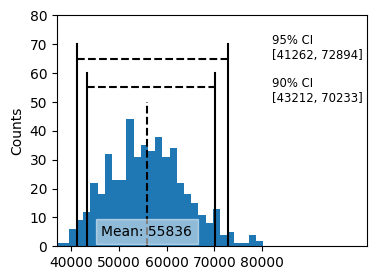

In [1]:
np.random.seed(seed=3)
# create a sample of 20 loan income data
sample20 = resample(loans_income, n_samples=20, replace=False)

results = []
for _ in range(500):
    sample = resample(sample20)
    results.append(sample.mean())
results = pd.Series(results)

confidence_interval = list(results.quantile([0.05, 0.95]))
ax = results.plot.hist(bins=30, figsize=(4, 3), color="C1")
ax.plot(confidence_interval, [55, 55], color="black", linestyle="--")
for x in confidence_interval:
    ax.plot([x, x], [0, 60], color="black")
ax.text(82000, 50,
        f"90% CI\n[{confidence_interval[0]:.0f}, {confidence_interval[1]:.0f}]",
       fontsize="small")

confidence_interval = list(results.quantile([0.025, 0.975]))
ax = results.plot.hist(bins=30, figsize=(4, 3))
ax.plot(confidence_interval, [65, 65], color="black", linestyle="--")
for x in confidence_interval:
    ax.plot([x, x], [0, 70], color="black")
ax.text(82000, 65,
        f"95% CI\n[{confidence_interval[0]:.0f}, {confidence_interval[1]:.0f}]",
       fontsize="small")
# ax.text(sum(confidence_interval) / 2, 264, "95 % interval",
#         horizontalalignment="center", verticalalignment="center")

meanIncome = results.mean()
ax.plot([meanIncome, meanIncome], [0, 50], color="black", linestyle="--")
ax.text(meanIncome, 5, f"Mean: {meanIncome:.0f}",
        bbox={"facecolor": "white", "edgecolor": "white", "alpha": 0.5},
        horizontalalignment="center", verticalalignment="center")
ax.set_ylim(0, 80)
ax.set_xlim(37000, 102000)
ax.set_xticks([40000, 50000, 60000, 70000, 80000])
ax.set_ylabel("Counts")
plt.show()

## Visualization of Distributions
### Poisson Distribution

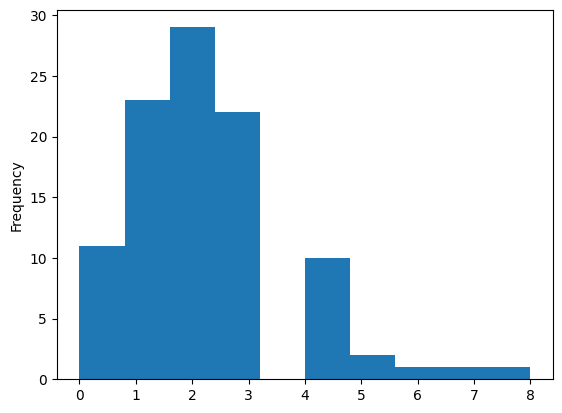

In [1]:
sample = stats.poisson.rvs(2, size=100)
pd.Series(sample).plot.hist()
plt.show()

### Exponential Distribution

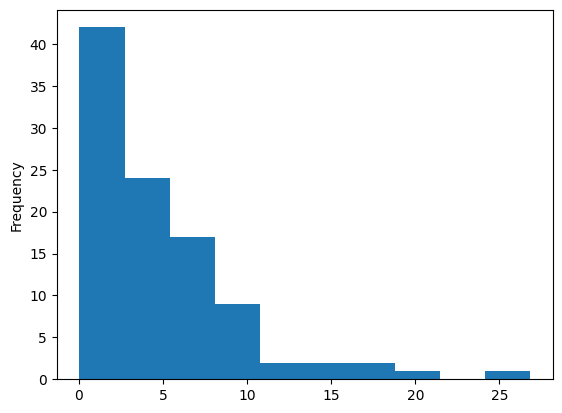

In [1]:
sample = stats.expon.rvs(scale=5, size=100)
pd.Series(sample).plot.hist()
plt.show()

### Weibull Distribution

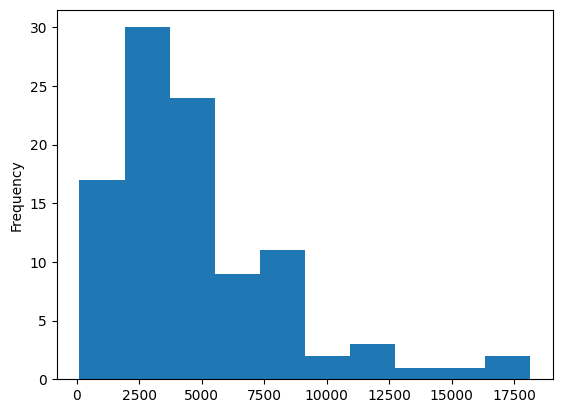

In [1]:
sample = stats.weibull_min.rvs(1.5, scale=5000, size=100)
pd.Series(sample).plot.hist()
plt.show()